# Analisis Exploratorio de Datos

## 1. Auditoria de datos
- ¿Cuántas filas y columnas tenemos?  
- ¿Cuáles son los tipos de datos?  
- ¿Parecen correctos?

In [3]:
import pandas as pd
import numpy as np

In [4]:
df_autos = pd.read_csv(r"C:\Users\jemma\Desktop\Ciencia Datos UVM\Python_DS\csv_datasets\Proyecto_autos\car_prices.csv\car_prices.csv")

- Filas y columnas del dataframe

# df_autos.shape

- Tipos de datos

In [8]:
df_autos.dtypes

year              int64
make             object
model            object
trim             object
body             object
transmission     object
vin              object
state            object
condition       float64
odometer        float64
color            object
interior         object
seller           object
mmr             float64
sellingprice    float64
saledate         object
dtype: object

- ¿Parecen correctos?

Sí, en general parecen corresctos los tipos de datos, excepto por la fecha, la cual aparece como un object (string) y debería ser un datetime object

## 2. Valores faltantes
- ¿Hay columnas con valores nulos?
- ¿Cuántos?

- Columnas con valores nulos y count of

In [13]:
#Devuelve la suma de valores NaN por columna
df_autos.isna().sum()

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64

## 3. Estadisticas generales
- ¿Cuál es el precio promedio de venta y el kilometraje (odometer) promedio de todos los autos?

- Precio promedio de venta:  **13611.358810** dolares

In [16]:
df_autos['sellingprice'].describe()

count    558825.000000
mean      13611.358810
std        9749.501628
min           1.000000
25%        6900.000000
50%       12100.000000
75%       18200.000000
max      230000.000000
Name: sellingprice, dtype: float64

- Promedio de kilometraje: **68320.017767** millas

In [18]:
df_autos['odometer'].describe()

count    558743.000000
mean      68320.017767
std       53398.542821
min           1.000000
25%       28371.000000
50%       52254.000000
75%       99109.000000
max      999999.000000
Name: odometer, dtype: float64

## 4. Top marcas
- ¿Cuáles son las 5 marcas (make) más frecuentes en el dataset?

In [20]:
#.unique devuelve los valores unicos de una serie
df_autos['make'].unique()

array(['Kia', 'BMW', 'Volvo', 'Nissan', 'Chevrolet', 'Audi', 'Ford',
       'Hyundai', 'Buick', 'Cadillac', 'Acura', 'Lexus', 'Infiniti',
       'Jeep', 'Mercedes-Benz', 'Mitsubishi', 'Mazda', 'MINI',
       'Land Rover', 'Lincoln', 'lincoln', 'Jaguar', 'Volkswagen',
       'Toyota', 'Subaru', 'Scion', 'Porsche', nan, 'bmw', 'Dodge',
       'FIAT', 'Chrysler', 'ford', 'Ferrari', 'Honda', 'GMC',
       'mitsubishi', 'Ram', 'smart', 'chevrolet', 'Bentley', 'chrysler',
       'pontiac', 'Pontiac', 'Saturn', 'Maserati', 'Mercury', 'HUMMER',
       'landrover', 'cadillac', 'land rover', 'mercedes', 'mazda',
       'toyota', 'lexus', 'gmc truck', 'honda', 'nissan', 'porsche',
       'Saab', 'Suzuki', 'dodge', 'subaru', 'Oldsmobile', 'oldsmobile',
       'hyundai', 'jeep', 'Isuzu', 'dodge tk', 'Geo', 'acura',
       'volkswagen', 'suzuki', 'kia', 'audi', 'Rolls-Royce', 'gmc',
       'maserati', 'mazda tk', 'mercury', 'buick', 'hyundai tk',
       'mercedes-b', 'vw', 'Daewoo', 'chev truck', 'f

In [21]:
df_autos['make'].value_counts().head()

make
Ford         93554
Chevrolet    60197
Nissan       53946
Toyota       39871
Dodge        30710
Name: count, dtype: int64

# Limpieza de Datos

## Estandarización de strings
Estandarizar columna 'make'

In [24]:
df_limpio = df_autos

In [25]:
df_limpio['make'] = df_limpio['make'].str.upper()

In [26]:
df_limpio['make'] = df_limpio['make'].str.strip()

In [27]:
df_limpio['make'].unique()

array(['KIA', 'BMW', 'VOLVO', 'NISSAN', 'CHEVROLET', 'AUDI', 'FORD',
       'HYUNDAI', 'BUICK', 'CADILLAC', 'ACURA', 'LEXUS', 'INFINITI',
       'JEEP', 'MERCEDES-BENZ', 'MITSUBISHI', 'MAZDA', 'MINI',
       'LAND ROVER', 'LINCOLN', 'JAGUAR', 'VOLKSWAGEN', 'TOYOTA',
       'SUBARU', 'SCION', 'PORSCHE', nan, 'DODGE', 'FIAT', 'CHRYSLER',
       'FERRARI', 'HONDA', 'GMC', 'RAM', 'SMART', 'BENTLEY', 'PONTIAC',
       'SATURN', 'MASERATI', 'MERCURY', 'HUMMER', 'LANDROVER', 'MERCEDES',
       'GMC TRUCK', 'SAAB', 'SUZUKI', 'OLDSMOBILE', 'ISUZU', 'DODGE TK',
       'GEO', 'ROLLS-ROYCE', 'MAZDA TK', 'HYUNDAI TK', 'MERCEDES-B', 'VW',
       'DAEWOO', 'CHEV TRUCK', 'FORD TK', 'PLYMOUTH', 'FORD TRUCK',
       'TESLA', 'AIRSTREAM', 'DOT', 'ASTON MARTIN', 'FISKER',
       'LAMBORGHINI', 'LOTUS'], dtype=object)

In [28]:
#diccionario de mapeo para realizar correciones con .replace
correcciones = {
    'GMC TRUCK':'GMC',
    'DODGE TK':'DODGE',
    'MAZDA TK':'MAZDA',
    'HYUNDAI TK': 'HYUNDAI',
    'MERCEDES-B':'MERCEDES-BENZ',
    'VW':'VOLKSWAGEN',
    'CHEV TRUCK':'CHEVROLET',
    'FORD TRUCK':'FORD',
    'FORD TK':'FORD',
    'MERCEDES':'MERCEDES-BENZ',
    'LANDROVER':'LAND ROVER',
    'DOT':'DODGE'
}

In [29]:
#Implementación del diccionario de mapeo para estandarizar make
df_limpio['make'] = df_limpio['make'].replace(correcciones)

In [30]:
df_limpio['make'].unique()

array(['KIA', 'BMW', 'VOLVO', 'NISSAN', 'CHEVROLET', 'AUDI', 'FORD',
       'HYUNDAI', 'BUICK', 'CADILLAC', 'ACURA', 'LEXUS', 'INFINITI',
       'JEEP', 'MERCEDES-BENZ', 'MITSUBISHI', 'MAZDA', 'MINI',
       'LAND ROVER', 'LINCOLN', 'JAGUAR', 'VOLKSWAGEN', 'TOYOTA',
       'SUBARU', 'SCION', 'PORSCHE', nan, 'DODGE', 'FIAT', 'CHRYSLER',
       'FERRARI', 'HONDA', 'GMC', 'RAM', 'SMART', 'BENTLEY', 'PONTIAC',
       'SATURN', 'MASERATI', 'MERCURY', 'HUMMER', 'SAAB', 'SUZUKI',
       'OLDSMOBILE', 'ISUZU', 'GEO', 'ROLLS-ROYCE', 'DAEWOO', 'PLYMOUTH',
       'TESLA', 'AIRSTREAM', 'ASTON MARTIN', 'FISKER', 'LAMBORGHINI',
       'LOTUS'], dtype=object)

In [31]:
df_limpio.loc[df_limpio['make'] == 'AIRSTREAM']

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
34900,2012,AIRSTREAM,interstate,rvb,NaN,automatic,wd3pf4cd5c5624350,ca,4.0,51971.0,black,tan,pdx auto wholesale llc,29500.0,71000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [32]:
df_limpio['make'].value_counts().head()

make
FORD         94001
CHEVROLET    60588
NISSAN       54017
TOYOTA       39966
DODGE        30957
Name: count, dtype: int64

## Manejo de fechas
Convertir 'saledate' a formato de fecha (datetime)

In [34]:
df_limpio['saledate'].loc[df_limpio['saledate'].isna()]

306447    NaN
406524    NaN
422358    NaN
429644    NaN
429660    NaN
429786    NaN
431905    NaN
457035    NaN
457803    NaN
522495    NaN
537706    NaN
543129    NaN
Name: saledate, dtype: object

In [35]:
pd.to_datetime(df_limpio['saledate'], errors = 'coerce',utc=True)

C:\Users\jemma\AppData\Local\Temp\ipykernel_18628\333286651.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df_limpio['saledate'], errors = 'coerce',utc=True)


0        2014-12-16 04:30:00+00:00
1        2014-12-16 04:30:00+00:00
2        2015-01-14 20:30:00+00:00
3        2015-01-28 20:30:00+00:00
4        2014-12-18 04:30:00+00:00
                    ...           
558832   2015-07-09 00:00:00+00:00
558833   2015-07-08 02:30:00+00:00
558834   2015-07-08 02:30:00+00:00
558835   2015-07-08 23:45:00+00:00
558836   2015-05-27 22:30:00+00:00
Name: saledate, Length: 558837, dtype: datetime64[ns, UTC]

## Decisiones sobre nulos
Evaluar la cantidad de valores nulos por columna

In [37]:
df_limpio.isna().sum()

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64

In [38]:
df_limpio = df_limpio.dropna(subset = ['make','body'] )

### Auditoria post-limpieza

In [40]:
print("--- Auditoría Post-Limpieza ---")
print(f"Filas originales: 558837") # Dato de tu shape anterior
print(f"Filas actuales: {df_limpio.shape[0]}")
print("\nNulos restantes en 'make':", df_limpio['make'].isnull().sum())
print("Top 5 Marcas normalizadas:\n", df_limpio['make'].value_counts().head())

--- Auditoría Post-Limpieza ---
Filas originales: 558837
Filas actuales: 545642

Nulos restantes en 'make': 0
Top 5 Marcas normalizadas:
 make
FORD         93554
CHEVROLET    60179
NISSAN       53946
TOYOTA       39871
DODGE        30710
Name: count, dtype: int64


### Eliminación de outliers

In [42]:
df_limpio = df_limpio.query('sellingprice > 500')
df_limpio = df_limpio.query('sellingprice < 230000')

In [43]:
df_limpio['sellingprice'].describe()

count    539336.000000
mean      13888.876758
std        9668.968882
min         520.000000
25%        7300.000000
50%       12400.000000
75%       18400.000000
max      183000.000000
Name: sellingprice, dtype: float64

### Eliminación de dataleakage

In [45]:
df_limpio.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate'],
      dtype='object')

In [46]:
df_limpio = df_limpio[['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller','sellingprice', 'saledate']]

In [47]:
df_limpio

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,sellingprice,saledate
0,2015,KIA,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,KIA,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,VOLVO,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,2015,KIA,K900,Luxury,Sedan,NaN,knalw4d4xf6019304,in,45.0,18255.0,silver,black,avis corporation,33000.0,Thu Jul 09 2015 07:00:00 GMT-0700 (PDT)
558833,2012,RAM,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30800.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558834,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,black,black,financial services remarketing (lease),34000.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558835,2015,NISSAN,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,11100.0,Thu Jul 09 2015 06:45:00 GMT-0700 (PDT)


# Visualización de datos (EDA Visual)
Realización de tres gráficos para responder tres preguntas de negocio

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

#Configuración estética
sns.set_style("whitegrid") # Pone una rejilla de fondo suave
plt.figure(figsize=(10,6)) # Tamaño base para los gráficos

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

## Precios
**¿La mayoría de los autos son baratos o caros? ¿Hay valores atípicos?**  
La distribución de los precios no es normal, no tiene cola por el lado izquierdo; en cambio, tiene cola por el lado derecho.  
En general, podría decirse que la mayoría de los autos son baratos, apoyados en la medio de 13734 dolares.  
Ahora bien, hay algunos valores atípicos, el modelo de auto más costoso parece tener un precio excesivamente caro (Ford-Escape - 230000 dolares)  
y hay tres registros de autos con un costo de 1 dolar.  
Además, es peculiar que la grafica comience tan cerca de cero con frecuencias tan altas.

<Axes: title={'center': 'Distribución de precios de venta'}, ylabel='Frequency'>

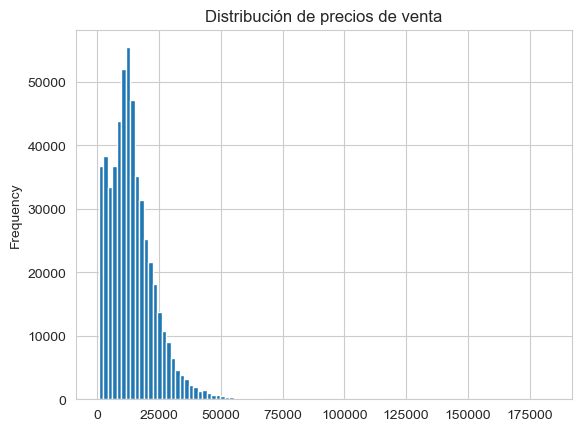

In [51]:
df_limpio['sellingprice'].plot(kind='hist', bins = 100, title = 'Distribución de precios de venta')

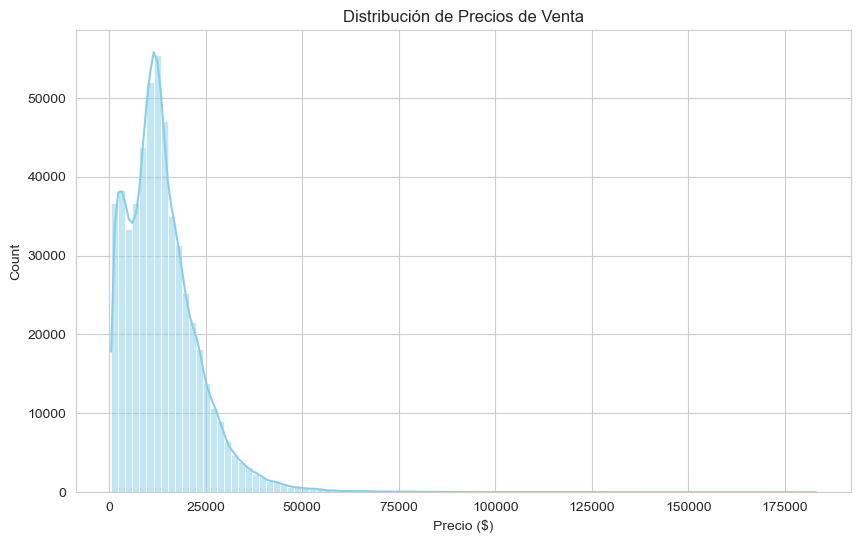

In [52]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_limpio, x='sellingprice', bins=100, color='skyblue', kde=True)
plt.title('Distribución de Precios de Venta')
plt.xlabel('Precio ($)')
plt.show()

In [53]:
df_limpio['sellingprice'].describe()

count    539336.000000
mean      13888.876758
std        9668.968882
min         520.000000
25%        7300.000000
50%       12400.000000
75%       18400.000000
max      183000.000000
Name: sellingprice, dtype: float64

In [54]:
df_limpio.loc[df_limpio['sellingprice']== 1]

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,sellingprice,saledate


In [55]:
df_limpio['sellingprice'].sort_values(ascending=False).head()

548169    183000.0
446949    173000.0
545523    171500.0
125095    169500.0
557570    169000.0
Name: sellingprice, dtype: float64

In [56]:
df_limpio.loc[df_limpio['sellingprice']  > 169000].head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,sellingprice,saledate
125095,2012,ROLLS-ROYCE,Ghost,Base,Sedan,automatic,sca664s58cux50727,fl,45.0,14316.0,black,beige,braman motorcars,169500.0,Wed Jan 14 2015 01:40:00 GMT-0800 (PST)
446949,2015,MERCEDES-BENZ,S-Class,S65 AMG,Sedan,automatic,wddug7kb2fa102347,ca,41.0,5277.0,white,white,mercedes-benz usa,173000.0,Thu May 21 2015 05:00:00 GMT-0700 (PDT)
545523,2013,ROLLS-ROYCE,Ghost,Base,sedan,automatic,sca664s52dux52152,fl,42.0,7852.0,white,beige,flag/landrover southpointe,171500.0,Wed Jun 17 2015 03:05:00 GMT-0700 (PDT)
548169,2011,FERRARI,458 Italia,Base,coupe,automatic,zff67nfa1b0178698,fl,46.0,12116.0,red,black,platinum motor cars,183000.0,Wed Jun 17 2015 03:40:00 GMT-0700 (PDT)


## Depreciación por uso
**¿Cuánto baja el precio a medida que sube el kilometraje? ¿Es lineal?**  
La relación que hay entre el millaje y el precio es exponencial negativa, descrita por una curva descendente.  
Se puede observar que el precio disminuye drasticamente en las primeras 50000 millas, donde se comienza a dibujar  
la curva, misma que comienza a aplanarse cerca de las 150000 millas.

<Axes: title={'center': 'Precio x Millaje'}, xlabel='odometer', ylabel='sellingprice'>

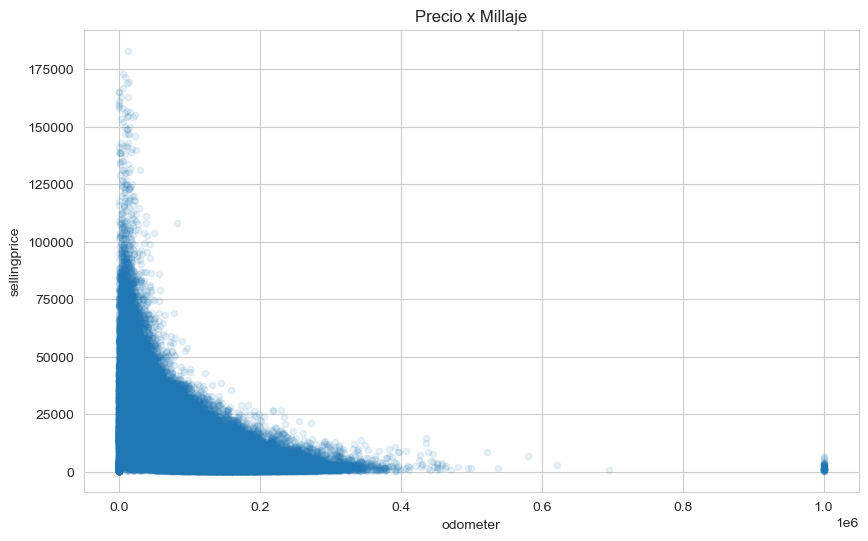

In [58]:
df_limpio.plot(
    kind='scatter', 
    x = 'odometer', 
    y = 'sellingprice', 
    title = 'Precio x Millaje',
    alpha = 0.1, 
    figsize=(10,6)
)

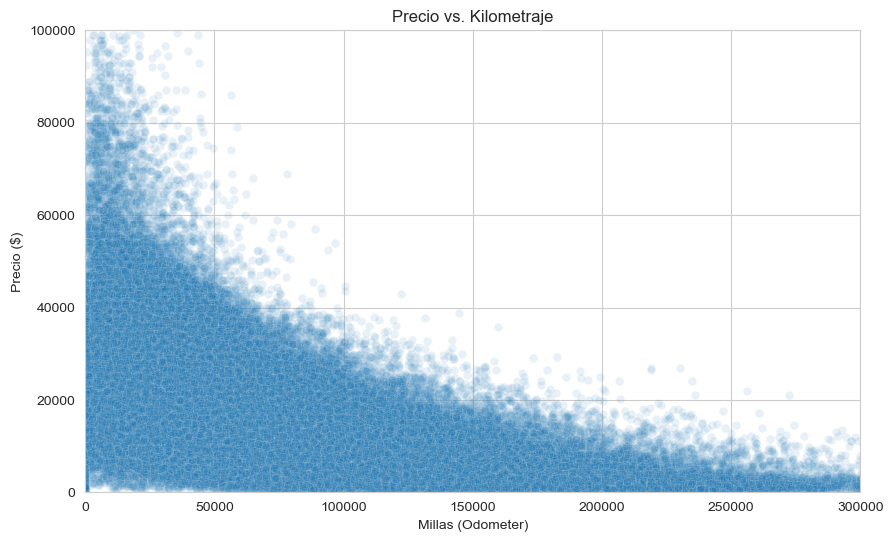

In [59]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_limpio, x='odometer', y='sellingprice', alpha=0.1)
plt.title('Precio vs. Kilometraje')
plt.xlabel('Millas (Odometer)')
plt.ylabel('Precio ($)')
# Truco de ingeniero: limitamos los ejes para no ver los errores de 999,999 por ahora
plt.xlim(0, 300000)
plt.ylim(0, 100000)
plt.show()

## Ranking de valor
**De las top 5 marcas que encontraste, ¿cuál tiene la mediana de precio más alta?**  
La marca de mayor media es Ford; sin embargo, poseé un valor atípico máximo, descrito previamente,  
por lo que esa podría ser la razón por la que es la de media más alta.

In [61]:
top_5_marcas = df_limpio['make'].value_counts().head().index
df_top_marcas = df_limpio[df_limpio['make'].isin(top_5_marcas)]

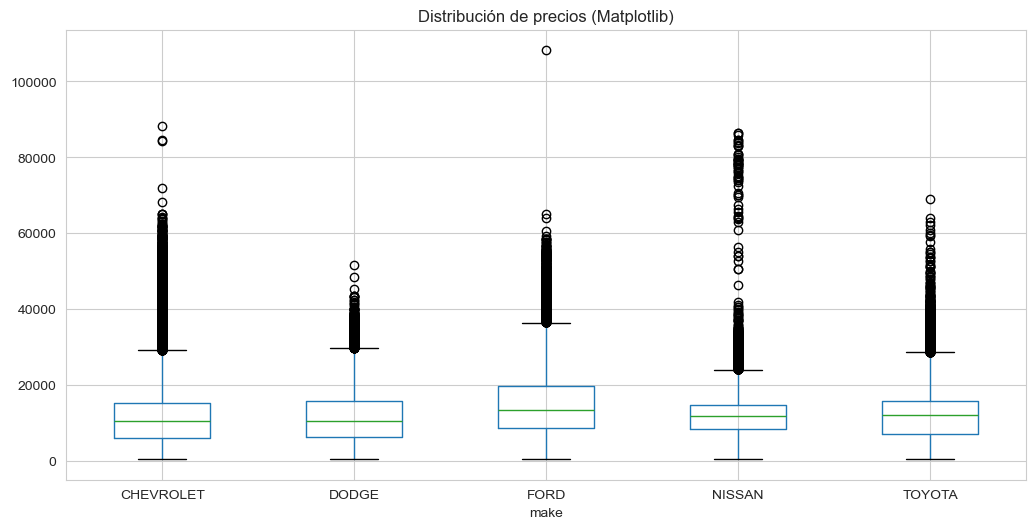

In [62]:
# Usando el método directo de pandas para boxplots agrupados
# Nota: el 'by' le dice cómo agrupar
df_top_marcas.boxplot(column='sellingprice', by='make', figsize=(12,6))
plt.title('Distribución de precios (Matplotlib)')
plt.suptitle('') # Esto borra un título automático feo que pone pandas
plt.show()

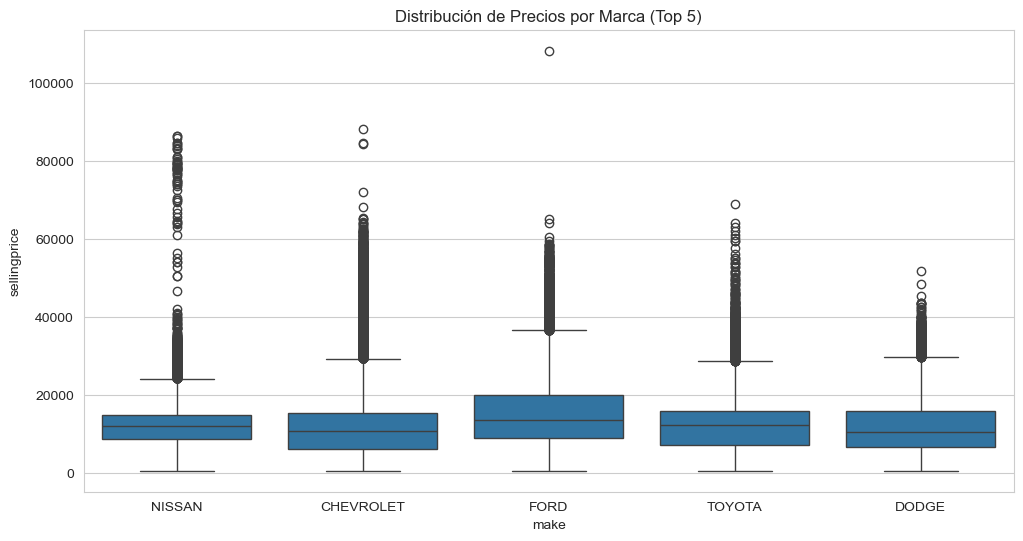

In [63]:
# Filtramos solo las top 5 marcas para no saturar el gráfico
top_brands = df_limpio['make'].value_counts().head(5).index
df_top = df_limpio[df_limpio['make'].isin(top_brands)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top, x='make', y='sellingprice')
plt.title('Distribución de Precios por Marca (Top 5)')
plt.show()

 # Matriz de Correlación
 Busqueda de variables más relevantes y matematicamente significativas  
 **¿El year (año) del auto tiene más correlación con el precio que el odometer?**  
 Con base en el heatmap, el valor del odometer y de year tienen la misma correlación con el precio,  
 pero, en sentidos inversos.  
 La correlación del precio con el año es positiva, mientras que con el odometer es negativa.  
 Además, la correlación entre el valor del odomter y el year es fuerte en sentido negativo,  
 lo que permite comprender que tengan una relación opuesta respecto al sellingprice.  
 Esto implica que, conforme aumenta el año, el millaje registrado en el odometro disminuye y viceversa,  
 por lo que el precio disminuye conforme el precio aumenta e incrementa conforme aumenta el año.

In [65]:
df_numerical = df_limpio[['year','condition','odometer','sellingprice']]
df_num_correlation =  df_numerical.corr()
df_num_correlation

,year,condition,odometer,sellingprice
year,1.000000,0.302003,-0.776474,0.574891
condition,0.302003,1.000000,-0.293197,0.299498
odometer,-0.776474,-0.293197,1.000000,-0.574926
sellingprice,0.574891,0.299498,-0.574926,1.000000


Text(0.5, 1.0, 'Heatmap de Correlación')

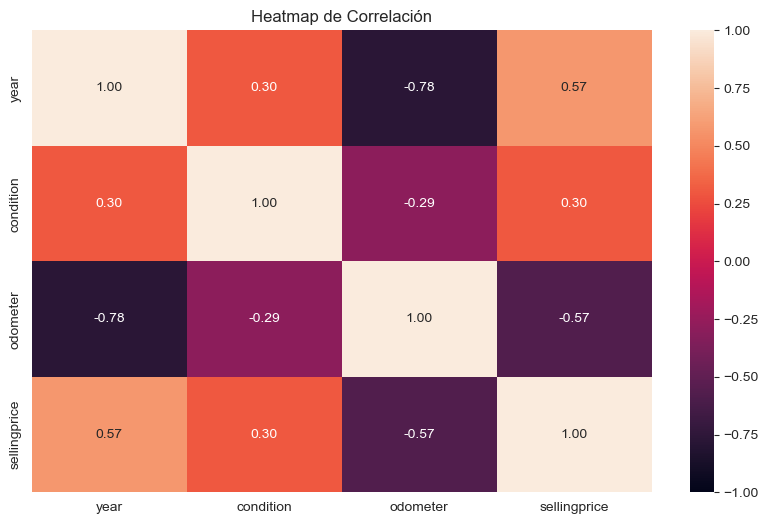

In [66]:
plt.figure(figsize = (10,6))
sns.heatmap(
    df_num_correlation,
    annot = True,
    fmt = ".2f",
    vmin = -1, vmax = 1
)
plt.title("Heatmap de Correlación")

# Feature Engeneering  
- Creación de vehicle_age (Edad del auto)
- Manejo de Variables Categóricas

## Creación de variable vehicle_age
Se define un nuevo DataFrame **'df_normalizado'** que se utilizará para pasar el dataframe a solo valores numericos  
para su posterior uso en un modelado de IA

In [69]:
df_limpio['vehicle_age'] = 2025 - df_limpio['year']

In [116]:
df_limpio.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'sellingprice',
       'saledate', 'vehicle_age'],
      dtype='object')

In [126]:
df_normalizado = df_limpio[[ 'make', 'model', 'vehicle_age', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'sellingprice',
       'saledate']]

In [128]:
df_normalizado

,make,model,vehicle_age,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,sellingprice,saledate
0,KIA,Sorento,10,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,KIA,Sorento,10,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,BMW,3 Series,11,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,VOLVO,S60,10,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,BMW,6 Series Gran Coupe,11,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,KIA,K900,10,Luxury,Sedan,NaN,knalw4d4xf6019304,in,45.0,18255.0,silver,black,avis corporation,33000.0,Thu Jul 09 2015 07:00:00 GMT-0700 (PDT)
558833,RAM,2500,13,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30800.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558834,BMW,X5,13,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,black,black,financial services remarketing (lease),34000.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558835,NISSAN,Altima,10,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,11100.0,Thu Jul 09 2015 06:45:00 GMT-0700 (PDT)
